<a href="https://colab.research.google.com/github/joaovvgoncalves22/FCE/blob/main/Tanque_com_Aquecimento_El%C3%A9trico_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

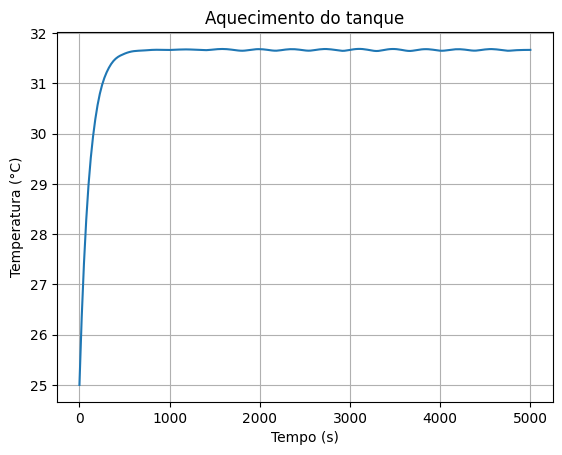

In [1]:
from dataclasses import dataclass
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt


# Classe com os parâmetros
@dataclass
class Parametros:

    Q: float
    U: float
    A: float
    Tamb: float
    m: float
    cp: float


# Função do modelo
def modelo(t, T, params):

    dTdt = (
        params.Q - params.U * params.A * (T[0] - params.Tamb)
    ) / (params.m * params.cp)

    return [dTdt]


# Função da simulação
def simular(tempo, params, T0):

    sol = solve_ivp(
        modelo,
        [tempo[0], tempo[-1]],
        [T0],
        t_eval=tempo,
        args=(params,)
    )

    return sol.t, sol.y[0]


# Valores do problema
params = Parametros(
    Q = 5000,
    U = 150,
    A = 5,
    Tamb = 25,
    m = 50,
    cp = 1670
)

# Temperatura inicial
T0 = 25

# Tempo da simulação
tempo = np.linspace(0, 5000, 200)

# Rodando a simulação
t, T = simular(tempo, params, T0)

# Gráfico
plt.plot(t, T)

plt.xlabel("Tempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Aquecimento do tanque")

plt.grid()

plt.show()